In [3]:
import pandas as pd
import numpy as np

# Import the dataset into a DataFrame.
df = pd.read_csv("/home/keenan/Airplane_Crashes_and_Fatalities_Since_1908.csv")
# Check the number of rows and columns the dataframe has.
print(f"The dataset has {df.shape[0]} rows and {df.shape[1]} columns.")

The dataset has 5268 rows and 13 columns.


In [4]:
# Print the last 75 rows of the dataframe
df.tail(75)

,Date,Time,Location,Operator,Flight #,Route,Type,Registration,cn/In,Aboard,Fatalities,Ground,Summary
5193,03/15/2008,08:15,"Nbagu, Nigeria",Trade Wings Aviation Ltd.,NaN,Lagos - Bebi Air Strip,Beechcraft 1900D,5N-JAH,UE-322,3.0,3.0,0.0,The plane crashed while en route. Wreckage was...
5194,04/03/2008,11:00,"Lawa, Suriname",Blue Wing Airlines,NaN,Paramaribo - Lawa,Antonov An-28,PZ-TSO,1AJ007-17,19.0,19.0,0.0,While attempting to land the crew aborted the ...
5195,04/09/2008,23:27,"Bundeena, Australia",Avtex Air Services,NaN,Sydney - Brisbane,Swearingen SA227AC Metroliner III,VH-OZA,AC-600,1.0,1.0,0.0,The pilot of the mail plane reported some mino...
5196,04/11/2008,22:15,"Chrisinau, Moldova",Kata Transportation,NaN,"Chrisinau, Moldova - Antalya, Turkey - Sudan",Antonov An-32,ST-AZL,3009,8.0,8.0,0.0,Just minutes after the take off the plane trie...
5197,04/15/2008,14:30,"Goma, Congo",Hewa Bora Airways,NaN,Goma - Kisangani - Kinshasa,McDonnell Douglas DC-9-51,9Q-CHN,47731,85.0,0.0,47.0,"While attempting to takeoff, the plane failed ..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...
5263,05/20/2009,06:30,"Near Madiun, Indonesia",Military - Indonesian Air Force,NaN,Jakarta - Maduin,Lockheed C-130 Hercules,A-1325,1982,112.0,98.0,2.0,"While on approach, the military transport cras..."
5264,05/26/2009,NaN,"Near Isiro, DemocratiRepubliCongo",Service Air,NaN,Goma - Isiro,Antonov An-26,9Q-CSA,5005,4.0,4.0,NaN,The cargo plane crashed while on approach to I...
5265,06/01/2009,00:15,"AtlantiOcean, 570 miles northeast of Natal, Br...",Air France,447,Rio de Janeiro - Paris,Airbus A330-203,F-GZCP,660,228.0,228.0,0.0,The Airbus went missing over the AtlantiOcean ...
5266,06/07/2009,08:30,"Near Port Hope Simpson, Newfoundland, Canada",Strait Air,NaN,Lourdes de BlanSablon - Port Hope Simpson,Britten-Norman BN-2A-27 Islander,C-FJJR,424,1.0,1.0,0.0,The air ambulance crashed into hills while att...


In [1]:
# Date - drop. "Date" is a critical field for placing the crashes.
# Time - fill with "Unknown". It is a secondary field which can be managed without.
# Location - drop. "Location" is very useful and is one of the main fields; which can't be imputed (it isn't numerical).
# Operator - fill with "Unknown". Can't be imputed since it isn't numerical and it's not a major field.
# Flight# - fill with "Unknown". They aren't meanignful at all.
# Route - drop or fill with "Unknown". Depends on its importance to the study since it can't be imputed.
# Type - drop or fill with "Unknown". Can be gotten from looking up registration; also depends on importance.
# Registration - fill with "Unknown". It is unique to each plane thus can't be imputed.
# cn/ln - fill with "Unknown". Also unique so can't be imputed.
# Aboard - drop or impute with median/mean. Dropping is an option in case it's important.
# Fatalities - drop. Is usually very crucial.
# Ground - Impute with 0. Ground casualties are rare.
# Summary - fill with "Unknown". Usually not crucial plus it can't be imputed.

In [5]:
fatality_locations = df[['Date', 'Location', 'Aboard', 'Fatalities']]


In [10]:
highest_fatalities = fatality_locations.sort_values(by="Fatalities", ascending=False).iloc[0]
print(f"The date with the highest number of recorded fatalities is {highest_fatalities["Date"]} with {highest_fatalities["Fatalities"]} fatalities.")

The date with the highest number of recorded fatalities is 03/27/1977 with 583.0 fatalities.


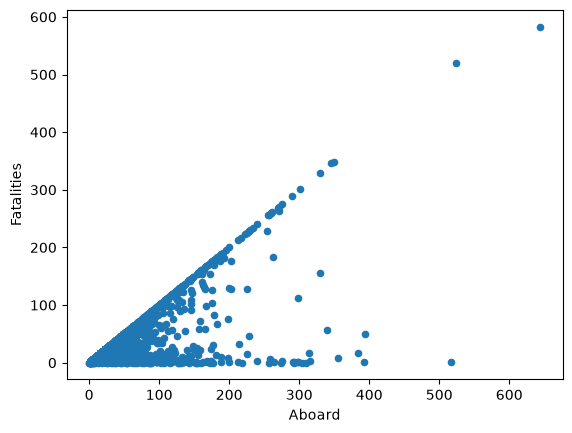

In [13]:
import matplotlib.pyplot as plt

df.plot.scatter(x="Aboard", y="Fatalities")
plt.show()

In [14]:
no_fatalities = df[df["Fatalities"] == 0]
print(f"There are {no_fatalities.shape[0]} crashes with no fatalities.")

There are 58 crashes with no fatalities.


In [18]:
fatality_locations[["Region", "Country"]] = fatality_locations["Location"].str.rsplit(", ", n=1, expand=True)
fatality_locations.head()

,Date,Location,Aboard,Fatalities,Region,Country
0,09/17/1908,"Fort Myer, Virginia",2.0,1.0,Fort Myer,Virginia
1,07/12/1912,"AtlantiCity, New Jersey",5.0,5.0,AtlantiCity,New Jersey
2,08/06/1913,"Victoria, British Columbia, Canada",1.0,1.0,"Victoria, British Columbia",Canada
3,09/09/1913,Over the North Sea,20.0,14.0,Over the North Sea,NaN
4,10/17/1913,"Near Johannisthal, Germany",30.0,30.0,Near Johannisthal,Germany


In [23]:
fatality_locations = fatality_locations.sort_values(by="Fatalities", ascending=False)
fatality_locations.head(100)

,Date,Location,Aboard,Fatalities,Region,Country
2963,03/27/1977,"Tenerife, Canary Islands",644.0,583.0,Tenerife,Canary Islands
3568,08/12/1985,"Mt. Osutaka, near Ueno Village, Japan",524.0,520.0,"Mt. Osutaka, near Ueno Village",Japan
4455,11/12/1996,"Near Charkhidadri, India",349.0,349.0,Near Charkhidadri,India
2726,03/03/1974,"Near Ermenonville, France",346.0,346.0,Near Ermenonville,France
3562,06/23/1985,"AtlantiOcean, 110 miles West of Ireland",329.0,329.0,AtlantiOcean,110 miles West of Ireland
...,...,...,...,...,...,...
4852,04/15/2002,"Busan, South Korea",166.0,128.0,Busan,South Korea
3198,01/21/1980,"Elburz Mtns., near Laskarak, Markazi, Iran",128.0,128.0,"Elburz Mtns., near Laskarak, Markazi",Iran
1701,12/16/1960,"Staten Island / Brooklyn, New York",128.0,128.0,Staten Island / Brooklyn,New York
5108,07/09/2006,"Irkutsk, Russia",203.0,128.0,Irkutsk,Russia


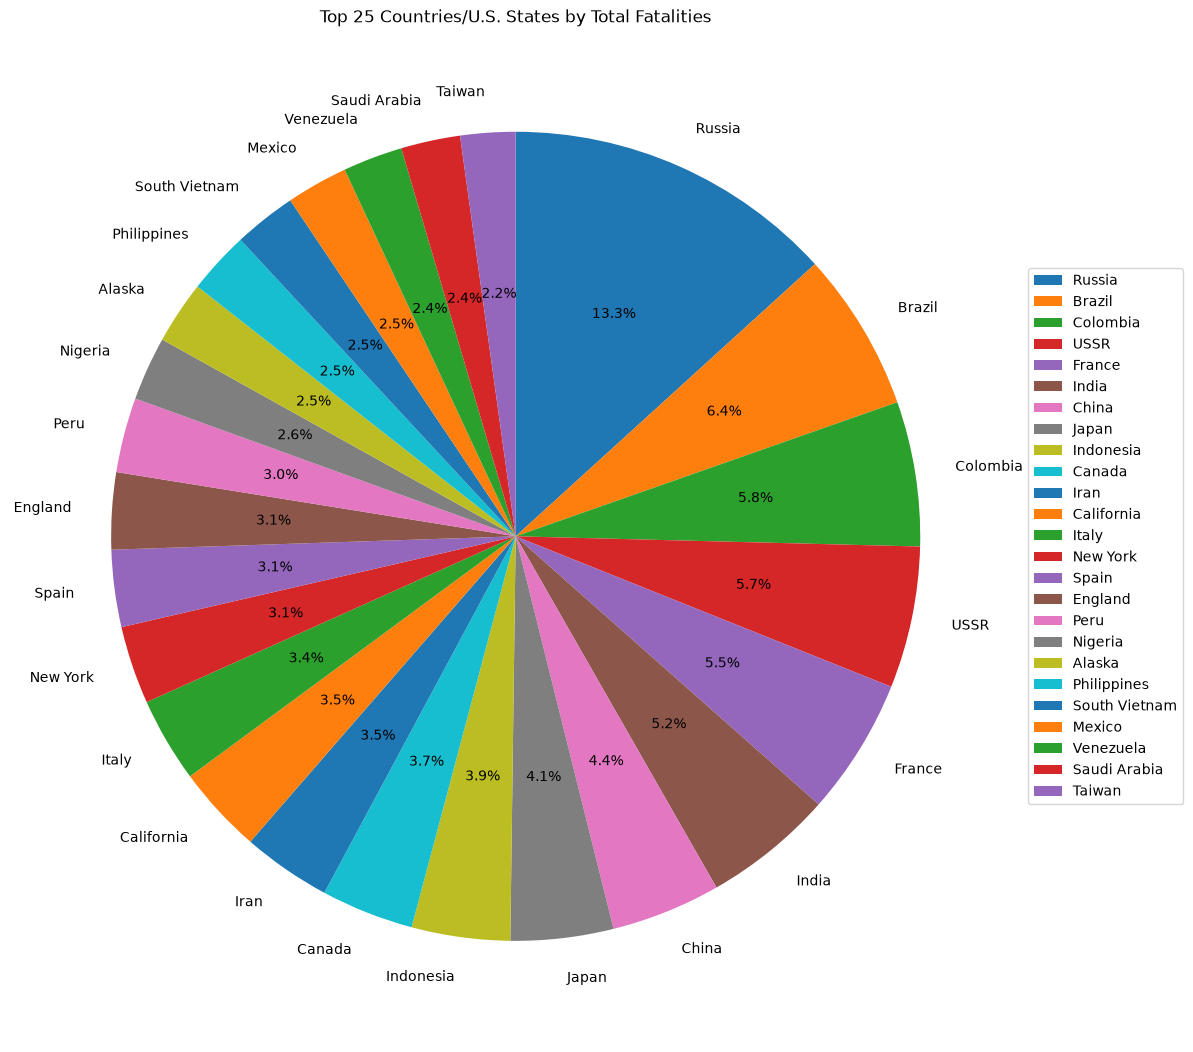

In [26]:
totals = fatality_locations.groupby('Country')['Fatalities'].sum()
top25 = totals.sort_values(ascending=False).head(25)

plt.figure(figsize=(12, 12))
top25.plot.pie(
    autopct='%1.1f%%',
    startangle=90,
    counterclock=False,
    ylabel=''
)
plt.title('Top 25 Countries/U.S. States by Total Fatalities')
plt.legend(top25.index, loc='center left', bbox_to_anchor=(1, 0.5))
plt.tight_layout()
plt.show()